In [56]:
## Loading Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [57]:
data= pd.read_csv("House Price Prediction Dataset.csv")

data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,4,2,1,1913,Urban,Fair,No,362654
1,2,4272,5,3,2,1962,Downtown,Good,Yes,1265841
2,3,3592,5,4,1,1980,Suburban,Good,Yes,720710
3,4,966,2,1,2,1984,Urban,Good,No,348862
4,5,4926,5,2,3,1950,Suburban,Good,No,899784


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [59]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,1000.500000,2786.209500,3.424000,2.533500,1.894500,1959.915000,6.491487e+05
std,577.494589,1295.146799,1.118414,0.897931,0.776963,35.984945,2.898893e+05
min,1.000000,501.000000,1.000000,1.000000,1.000000,1900.000000,1.174470e+05
25%,500.750000,1653.000000,3.000000,2.000000,1.000000,1928.000000,4.279265e+05
50%,1000.500000,2833.000000,3.000000,2.000000,2.000000,1959.000000,6.162415e+05
75%,1500.250000,3887.500000,4.000000,3.000000,3.000000,1990.000000,8.271345e+05
max,2000.000000,4999.000000,5.000000,4.000000,3.000000,2023.000000,1.739193e+06


In [60]:
print(data.columns)

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


In [61]:
print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (2000, 10)
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location Condition  \
0   1  1360         4          2       1       1913     Urban      Fair   
1   2  4272         5          3       2       1962  Downtown      Good   
2   3  3592         5          4       1       1980  Suburban      Good   
3   4   966         2          1       2       1984     Urban      Good   
4   5  4926         5          2       3       1950  Suburban      Good   

  Garage    Price  
0     No   362654  
1    Yes  1265841  
2    Yes   720710  
3     No   348862  
4     No   899784  


In [62]:
# 2. Handle Missing Values
data = data.fillna(data.median(numeric_only=True))

In [63]:
# 3. Feature Engineering
data["Age"] = 2026 - data["YearBuilt"]

In [64]:
# One-Hot Encode Categorical Variables
data_encoded = pd.get_dummies(data, columns=['Location', 'Condition', 'Garage'], drop_first=True)

# Features and target
X = data_encoded.drop(["Price", "Id"], axis=1)
y = data_encoded["Price"]

In [65]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# 6. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [67]:
# 7. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
# 8. Make Predictions
y_pred = model.predict(X_test)

In [69]:
# 9. Model Evaluation
r2 = r2_score(y_test, y_pred)

In [73]:
print("\nModel Performance")
print("R² Score:", r2)


Model Performance
R² Score: 0.9387030264413471


In [71]:
# 10. Show Sample Predictions
print("\nSample Predictions (First 5)")
print("Predicted:", y_pred[:5])
print("Actual:", y_test.iloc[:5].values)


Sample Predictions (First 5)
Predicted: [195234.36273688 657918.28250756 614225.96950064 224236.93570272
 550533.72557656]
Actual: [225455 611390 534883 308485 514313]


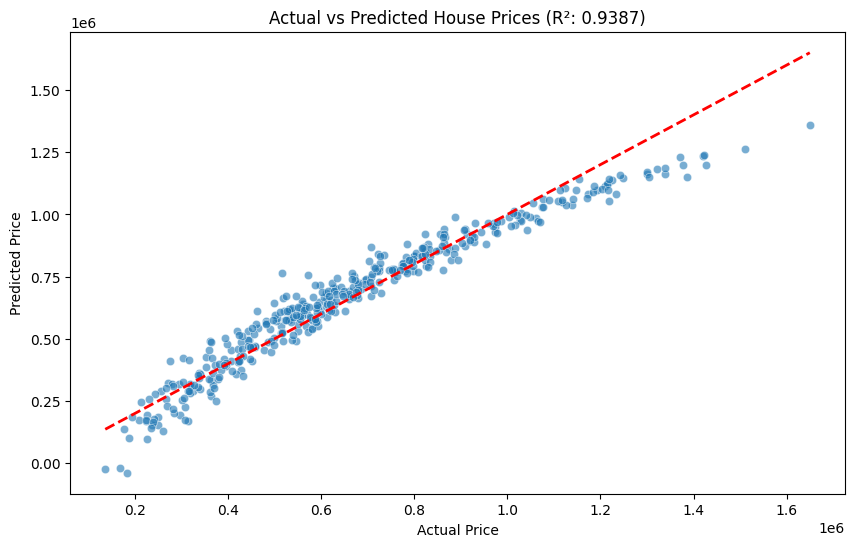

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted House Prices (R²: {r2:.4f})')
plt.show()